In [ ]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(),'..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from src.word_process import sudachi_tokenize
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("../data/processed/edinet_analysis_data_clns.csv")
df.head()

,company_name,business_description,business_risks,filename
0,テクミラホールディングス株式会社,3 事業の内容 当社グループは、テクミラホールディングス株式会社(当社)及び連結子会社9社、...,3 事業等のリスク 以下において、投資家に対する積極的な情報開示の観点から、当社グループの事...,S100VUJU.zip
1,IPSホールディングス株式会社,3 事業の内容 当社グループは、当社並びに連結子会社2社、非連結子会社1社、関連会社1社で構...,3 事業等のリスク 有価証券報告書に記載した事業の状況、経理の状況等に関する事項のうち、経営...,S100WRPN.zip
2,株式会社フォーバル・リアルストレート,3 事業の内容 当社は、企業のソリューションニーズが最も高まるオフィス移転時において、不動産...,3 事業等のリスク 当社の経営成績及び財政状態等に影響を及ぼす可能性のある主なリスクは以下の...,S100W4QO.zip
3,鷹之台ゴルフ株式会社,3 事業の内容 当社は、所有土地のすべてを一般社団法人鷹之台カンツリー倶楽部に賃貸しており、...,3 事業等のリスク 当社の売上高は、一般社団法人鷹之台カンツリー倶楽部へのゴルフ場用地の土地...,S100VWXC.zip
4,株式会社ジェーソン,3 事業の内容 当社グループの概要当社グループ(当社及び当社の関係会社)は、当社、連結子会社...,3 事業等のリスク 有価証券報告書に記載した事業の状況、経理の状況等に関する事項のうち、経営...,S100VUA9.zip


★名詞だけを抜き出す

In [6]:
df["nouns"] = df["business_description"].apply(sudachi_tokenize)

df.head()

,company_name,business_description,business_risks,filename,nouns
0,テクミラホールディングス株式会社,3 事業の内容 当社グループは、テクミラホールディングス株式会社(当社)及び連結子会社9社、...,3 事業等のリスク 以下において、投資家に対する積極的な情報開示の観点から、当社グループの事...,S100VUJU.zip,事業 内容 当社 グループ テクミラホールディングス 株式会社 当社 連結 子会社 関連会社...
1,IPSホールディングス株式会社,3 事業の内容 当社グループは、当社並びに連結子会社2社、非連結子会社1社、関連会社1社で構...,3 事業等のリスク 有価証券報告書に記載した事業の状況、経理の状況等に関する事項のうち、経営...,S100WRPN.zip,事業 内容 当社 グループ 当社 並び 連結 子会社 連結 子会社 関連会社 構成 販売 物...
2,株式会社フォーバル・リアルストレート,3 事業の内容 当社は、企業のソリューションニーズが最も高まるオフィス移転時において、不動産...,3 事業等のリスク 当社の経営成績及び財政状態等に影響を及ぼす可能性のある主なリスクは以下の...,S100W4QO.zip,事業 内容 当社 企業 ソリューション ニーズ オフィス 移転 不動産 物件 仲介 内装 工...
3,鷹之台ゴルフ株式会社,3 事業の内容 当社は、所有土地のすべてを一般社団法人鷹之台カンツリー倶楽部に賃貸しており、...,3 事業等のリスク 当社の売上高は、一般社団法人鷹之台カンツリー倶楽部へのゴルフ場用地の土地...,S100VWXC.zip,事業 内容 当社 所有 土地 すべて 一般社団法人 鷹之 カンツリー 倶楽部 賃貸 賃貸借契...
4,株式会社ジェーソン,3 事業の内容 当社グループの概要当社グループ(当社及び当社の関係会社)は、当社、連結子会社...,3 事業等のリスク 有価証券報告書に記載した事業の状況、経理の状況等に関する事項のうち、経営...,S100VUA9.zip,事業 内容 当社 グループ 概要 当社 グループ 当社 当社 関係会社 当社 連結 子会社 ...


In [7]:
from collections import Counter

all_words = " ".join(df["nouns"]).split()

common_words = Counter(all_words).most_common(10)
rare_words = Counter(all_words).most_common()[:-11:-1]
for word, count in common_words:
    print(f"{word}: {count}")
for word, count in rare_words:
    print(f"{word}: {count}")


事業: 44042
当社: 41450
こと: 19931
サービス: 19626
販売: 18878
グループ: 14605
株式会社: 14083
子会社: 13216
提供: 12528
製造: 10301
521: 1
844: 1
セイロップシステム: 1
Liblock: 1
機関保証: 1
あんしん保証: 1
AIFULPublicCompanyLimited: 1
AIRA: 1
APCInternationalIndonesiaAPPlaceHongKongCo: 1
Nacamoguro: 1


★全体の単語数とユニークな単語の確認

In [8]:
##事業内容のユニークな名詞の数=setを使おう
##事業内容のヌルユニークな名詞の数=listを使おう
all_unique_words = set(" ".join(df["nouns"]).split())
all_nunique_words = list(" ".join(df["nouns"]).split())
print(f"全企業の事業内容に含まれるユニークな名詞の数: {len(all_unique_words)}語")
print(f"全企業の事業内容に含まれるヌルユニークな名詞の数: {len(all_nunique_words)}語")

全企業の事業内容に含まれるユニークな名詞の数: 82600語
全企業の事業内容に含まれるヌルユニークな名詞の数: 1592974語


★単語数の可視化（ヒストグラム）

/tmp/ipykernel_4718/2437017193.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(plot_data['word'], fontproperties=font_prop, rotation=90)


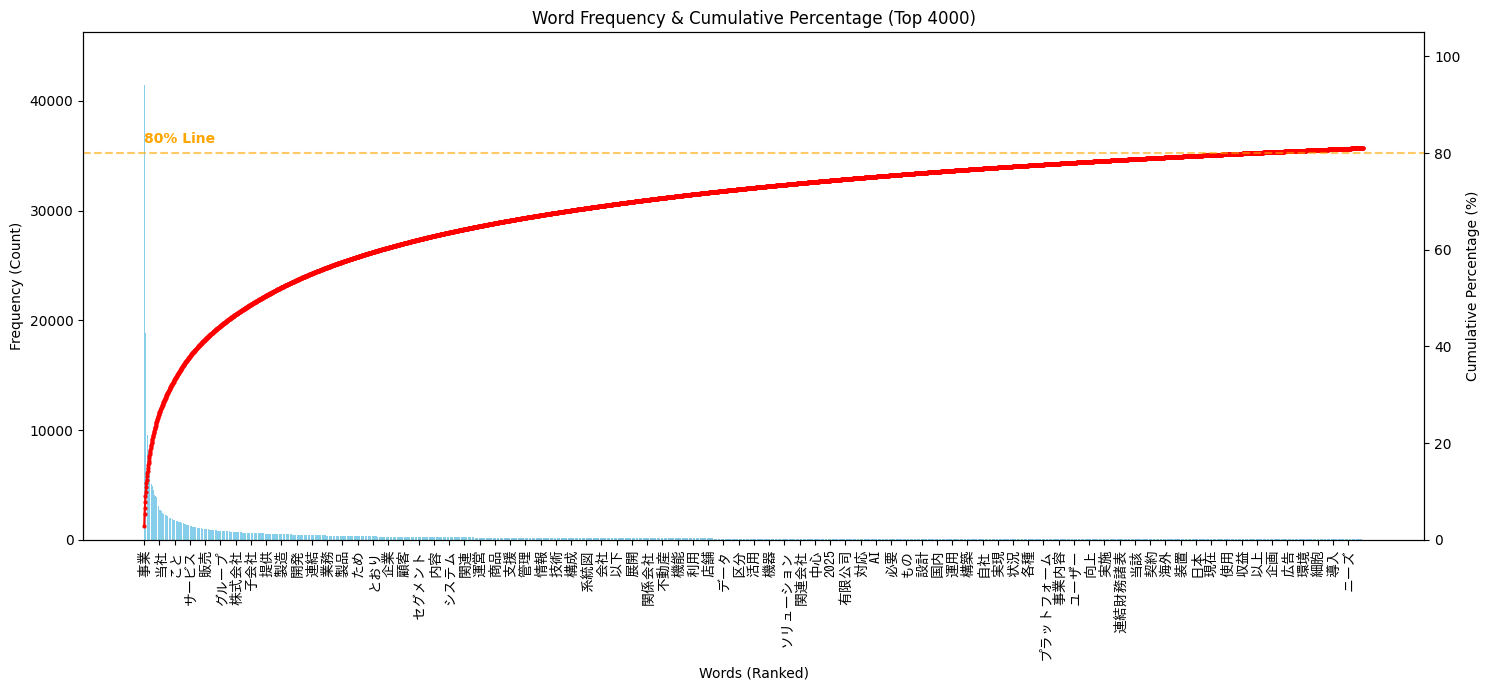

In [9]:
# Linuxの標準フォント（MSゴシック）のパスを直接指定
# fc-listの結果から、確実にあるパスを指定
font_path = "/usr/share/fonts/opentype/ipafont-gothic/ipag.ttf"
font_prop = fm.FontProperties(fname=font_path)

# 1. 単語の出現総数をカウント
all_words = " ".join(df["nouns"]).split()
word_counts = Counter(all_words)

# 2. データフレーム化してソート
counts_df = pd.DataFrame(word_counts.most_common(), columns=['word', 'count'])

# 3. 累積比率を計算
counts_df['cumulative_percent'] = counts_df['count'].cumsum() / counts_df['count'].sum() * 100

top_n = 4000
plot_data = counts_df.head(top_n)

fig, ax1 = plt.subplots(figsize=(15, 7))

# 棒グラフ：単語の出現回数
ax1.bar(plot_data['word'], plot_data['count'], color='skyblue', label='Word Count')
xticks = np.arange(0, len(plot_data['word'].index), 50)
ax1.set_xticklabels(plot_data['word'], fontproperties=font_prop, rotation=90)
ax1.set_xticks(xticks)
ax1.set_ylabel('Frequency (Count)')
ax1.set_xlabel('Words (Ranked)')
ax1.tick_params(axis='x', rotation=90)

# 双子のアキシスを作成（折れ線用）
ax2 = ax1.twinx()
# 折れ線グラフ：累積比率
ax2.plot(plot_data['word'], plot_data['cumulative_percent'], color='red', marker='o', ms=2, label='Cumulative %')
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_ylim(0, 105)

# 80%のラインに補助線を引く（パレートの法則の目安）
ax2.axhline(80, color='orange', linestyle='--', alpha=0.6)
ax2.text(0, 82, '80% Line', color='orange', fontweight='bold')

plt.title(f'Word Frequency & Cumulative Percentage (Top {top_n})')
plt.tight_layout()
plt.show()


★TF-IDF

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
# グラフの左端（最頻出）から「これは特徴にならない」と判断したものをリスト化
# wordをインデックスに設定してからスライスし、リストに戻す
custom_stop_words = plot_data.set_index("word").loc[:"内容"].index.tolist()

# ベクトライザーの設定
# max_df=0.5 は、全企業の50%以上に出現する単語を無視する設定
vec = TfidfVectorizer(
    stop_words=custom_stop_words,
    max_df=0.5, 
    min_df=5  # 5社未満にしか出ないレアすぎる単語もノイズとしてカット
)

tfidf_matrix = vec.fit_transform(df["nouns"])
print(f"TF-IDF行列の形状: {tfidf_matrix.shape}")
print(f"TF-IDF行列の一行目の形状: {tfidf_matrix[0].shape}")

TF-IDF行列の形状: (4229, 12899)
TF-IDF行列の一行目の形状: (1, 12899)


In [8]:
from sklearn.metrics.pairwise import cosine_similarity
# 全企業間の類似度を計算
similarity_matrix = cosine_similarity(tfidf_matrix)

# 例えば、0番目の企業に似ている順に並び替え
target_idx = 1806
print(df["company_name"][target_idx])
sim_scores = list(enumerate(similarity_matrix[target_idx]))
sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

# 上位5社を表示
for idx, score in sim_scores[1:11]:
    print(f"企業: {df['company_name'].iloc[idx]}, 類似度: {score:.3f}")

キヤノン株式会社
企業: キヤノン電子株式会社, 類似度: 0.645
企業: キヤノンマーケティングジャパン株式会社, 類似度: 0.524
企業: 株式会社オハラ, 類似度: 0.255
企業: 株式会社リコー, 類似度: 0.204
企業: 芝浦メカトロニクス株式会社, 類似度: 0.204
企業: TOWA株式会社, 類似度: 0.197
企業: 日本碍子株式会社, 類似度: 0.196
企業: カシオ計算機株式会社, 類似度: 0.183
企業: パルステック工業株式会社, 類似度: 0.183
企業: 株式会社村田製作所, 類似度: 0.178


In [9]:
import umap

# 1.3万次元を4次元に圧縮
reducer = umap.UMAP(n_components=4, random_state=42)
embedding = reducer.fit_transform(tfidf_matrix)

/home/manaty/financial-contagion-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/manaty/financial-contagion-analysis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/manaty/financial-contagion-analysis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(4229, 4)


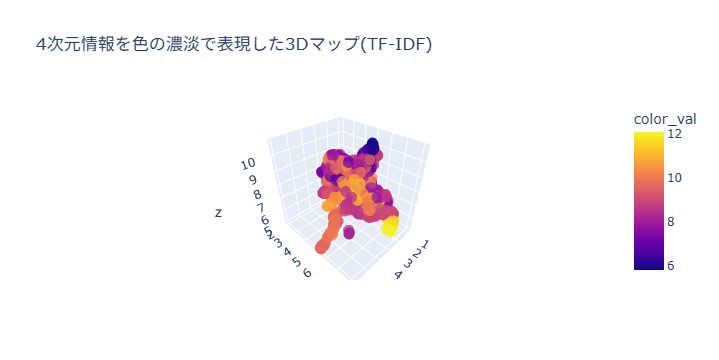

In [10]:
import umap
import plotly.express as px

# --- UMAPで1.3万次元を4次元にギュッと凝縮 ---
# n_neighbors: 値が小さいと局所的な構造、大きいと全体の構造を重視する
# min_dist: 点同士の最低距離。小さいと「島」がくっきり分かれる
reducer = umap.UMAP(n_components=4, n_neighbors=15, min_dist=0.1, random_state=42)
embedding_4d = reducer.fit_transform(tfidf_matrix)
print(embedding_4d.shape)
# --- ② 座標をDataFrameに結合 ---
df_4d = df.copy()
df_4d['x'] = embedding_4d[:, 0]
df_4d['y'] = embedding_4d[:, 1]
df_4d['z'] = embedding_4d[:, 2]
df_4d['color_val'] = embedding_4d[:, 3]
# --- ③ Plotlyで3D散布図を作成 ---
fig = px.scatter_3d(
    df_4d, 
    x='x', y='y', z='z',
    color='color_val',
    hover_name='company_name',     # カーソルを合わせた時に企業名を表示
    # text='company_name',         # 全ての点に名前を表示したい場合はこちら（重いので注意）
    opacity=0.7,                   # 点の透明度
    title='4次元情報を色の濃淡で表現した3Dマップ(TF-IDF)'
)

# 点のサイズを小さくして見やすくする
fig.update_traces(marker=dict(size=3))

# 表示！
fig.show()

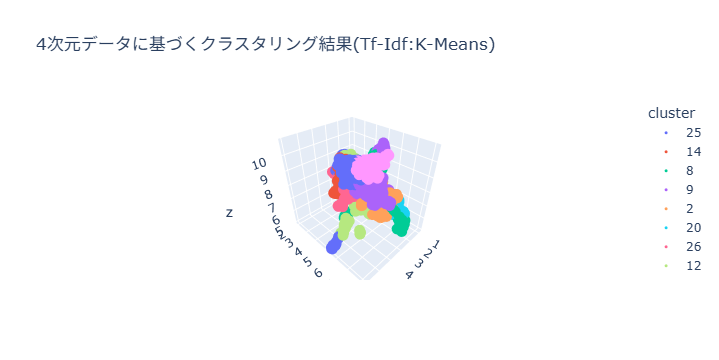

In [11]:
from sklearn.cluster import KMeans

# 4次元のデータを使ってクラスタリング（例：33グループ）
kmeans = KMeans(n_clusters =33, random_state=42)
df_4d["cluster"] = kmeans.fit_predict(embedding_4d).astype(str)

fig = px.scatter_3d(
    df_4d, x='x', y='y', z='z',
    color ='cluster',
    hover_name='company_name',
    title='4次元データに基づくクラスタリング結果(Tf-Idf:K-Means)'
)
fig.update_traces(marker=dict(size=3))
fig.show()

★ベクトル演算

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

def corporate_arithmetic(target_name:str, plus_name=None, minus_name=None, top_n=10):
    try:
        
        target_idx = df[df["company_name"] ==  target_name].index[0]
        vec = tfidf_matrix[target_idx].toarray()

        formula_str = target_name
        if minus_name:
            minus_idx = df[df["company_name"] == minus_name].index[0]
            vec = vec - tfidf_matrix[minus_idx].toarray()
            formula_str += f" - {minus_name}"

        if plus_name:
            plus_idx = df[df["company_name"] == plus_name].index[0]
            vec = vec + tfidf_matrix[plus_idx].toarray()
            formula_str += f" + {plus_name}"

        sim = cosine_similarity(vec, tfidf_matrix)

        sim_indices = sim[0].argsort()[::-1]

        print(f"--- 計算式: {formula_str} ---")
        count = 0
        for idx in sim_indices:
            name = df.iloc[idx]["company_name"]

            if name not in [target_name, minus_name, plus_name]:
                print(f"{count+1}位： {name}(類似度:{sim[0][idx]:.3f})")
                count += 1
            if count >= top_n:
                break
    except IndexError:
        print("指定された企業名がデータ内に見つかりませんでした。")
    

★会社自体の加算減算は可能だが、単語自体を引くことは不可能

In [14]:
corporate_arithmetic("キヤノン株式会社", minus_name="カメラ")

指定された企業名がデータ内に見つかりませんでした。


In [15]:
df.head()

,company_name,business_description,business_risks,filename,nouns
0,テクミラホールディングス株式会社,3 事業の内容 当社グループは、テクミラホールディングス株式会社(当社)及び連結子会社9社、...,3 事業等のリスク 以下において、投資家に対する積極的な情報開示の観点から、当社グループの事...,S100VUJU.zip,事業 内容 当社 グループ テクミラホールディングス 株式会社 当社 連結 子会社 関連会社...
1,IPSホールディングス株式会社,3 事業の内容 当社グループは、当社並びに連結子会社2社、非連結子会社1社、関連会社1社で構...,3 事業等のリスク 有価証券報告書に記載した事業の状況、経理の状況等に関する事項のうち、経営...,S100WRPN.zip,事業 内容 当社 グループ 当社 並び 連結 子会社 連結 子会社 関連会社 構成 販売 物...
2,株式会社フォーバル・リアルストレート,3 事業の内容 当社は、企業のソリューションニーズが最も高まるオフィス移転時において、不動産...,3 事業等のリスク 当社の経営成績及び財政状態等に影響を及ぼす可能性のある主なリスクは以下の...,S100W4QO.zip,事業 内容 当社 企業 ソリューション ニーズ オフィス 移転 不動産 物件 仲介 内装 工...
3,鷹之台ゴルフ株式会社,3 事業の内容 当社は、所有土地のすべてを一般社団法人鷹之台カンツリー倶楽部に賃貸しており、...,3 事業等のリスク 当社の売上高は、一般社団法人鷹之台カンツリー倶楽部へのゴルフ場用地の土地...,S100VWXC.zip,事業 内容 当社 所有 土地 すべて 一般社団法人 鷹之 カンツリー 倶楽部 賃貸 賃貸借契...
4,株式会社ジェーソン,3 事業の内容 当社グループの概要当社グループ(当社及び当社の関係会社)は、当社、連結子会社...,3 事業等のリスク 有価証券報告書に記載した事業の状況、経理の状況等に関する事項のうち、経営...,S100VUA9.zip,事業 内容 当社 グループ 概要 当社 グループ 当社 当社 関係会社 当社 連結 子会社 ...


★SBERT（Sentence-BERT）の活用(82600次元→768次元に圧縮)

In [20]:
'''
from sentence_transformers import SentenceTransformer
#日本語対応のモデルをロード
model = SentenceTransformer('intfloat/multilingual-e5-base')
#企業の事業内容を一気にベクトル化
sentences = df["business_description"].tolist()
business_embeddings = model.encode(sentences)

#学習時間およそ30分
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('intfloat/multilingual-e5-base')
'''

'\nfrom sentence_transformers import SentenceTransformer\n#日本語対応のモデルをロード\nmodel = SentenceTransformer(\'intfloat/multilingual-e5-base\')\n#企業の事業内容を一気にベクトル化\nsentences = df["business_description"].tolist()\nbusiness_embeddings = model.encode(sentences)\n\n#学習時間およそ30分\nfrom sentence_transformers import SentenceTransformer\nmodel = SentenceTransformer(\'intfloat/multilingual-e5-base\')\n'

次回すぐに使えるように、保存

In [21]:
'''
次回のために保存
np.save("business_embeddings.npy", business_embeddings)

df.to_pickle("company_data_with_sbert.pkl")
print("保存完了！ business_embeddings.npy と company_data_with_sbert.pkl が作成されました。")
'''

'\n次回のために保存\nnp.save("business_embeddings.npy", business_embeddings)\n\ndf.to_pickle("company_data_with_sbert.pkl")\nprint("保存完了！ business_embeddings.npy と company_data_with_sbert.pkl が作成されました。")\n'

In [22]:
# テスト読み込み
test_embeddings = np.load('../models/business_embeddings.npy')
test_df = pd.read_pickle('../models/company_data_with_sbert.pkl')

print(f"ベクトルの形状: {test_embeddings.shape}") # (4229, 768) と出れば成功
print(f"データフレームの行数: {len(test_df)}")   # 4229 と出れば成功

ベクトルの形状: (4229, 768)
データフレームの行数: 4229


In [23]:
from sklearn.metrics.pairwise import cosine_similarity

def quick_search(query_text, embeddings, df, top_n=10):
    # e5モデルのルール通り "query: " を付与
    query_vec = model.encode([f"query: {query_text}"])
    
    # コサイン類似度を計算
    sims = cosine_similarity(query_vec, embeddings)[0]
    
    # スコアをdfに追加してソート
    df_result = df.copy()
    df_result['score'] = sims
    return df_result.sort_values('score', ascending=False).head(top_n)

# 実行例
# res = quick_search("半導体の国内生産を強化する政府支援が決定", business_embeddings, df)
# print(res[['company_name', 'score']])

In [29]:
res = quick_search("日焼けしたキティやシナモン、クロミたちがかわいい♪ 夏仕様のフィギュア付き食玩が登場」", test_embeddings, df)
print(res[['company_name', 'score']])

         company_name     score
3912           株式会社壽屋  0.817356
3566         dely株式会社  0.815155
639    株式会社伸和ホールディングス  0.814341
3248       株式会社キッズスター  0.808873
3410  オイシックス・ラ・大地株式会社  0.807694
1755      株式会社スタジオアタオ  0.807667
806            株式会社大冷  0.807096
3730       フジコピアン株式会社  0.806722
2832        株式会社デルソーレ  0.805121
2995        Retty株式会社  0.805035


In [25]:
tfidf_matrix.shape

(4229, 12899)

/home/manaty/financial-contagion-analysis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


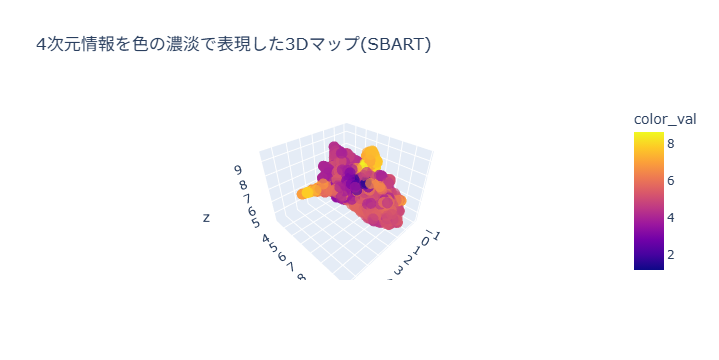

In [27]:
import umap
import plotly.express as px

# --- ① UMAPで768次元を3次元にギュッと凝縮 ---
# n_neighbors: 値が小さいと局所的な構造、大きいと全体の構造を重視します
# min_dist: 点同士の最低距離。小さいと「島」がくっきり分かれます
reducer = umap.UMAP(n_components=4, n_neighbors=5, min_dist=0.1, random_state=42)
embedding_4d = reducer.fit_transform(test_embeddings)

# --- ② 座標をDataFrameに結合 ---
df_4d = df.copy()
df_4d['x'] = embedding_4d[:, 0]
df_4d['y'] = embedding_4d[:, 1]
df_4d['z'] = embedding_4d[:, 2]
df_4d['color_val'] = embedding_4d[:, 3]
# --- ③ Plotlyで3D散布図を作成 ---
fig = px.scatter_3d(
    df_4d, 
    x='x', y='y', z='z',
    color='color_val',
    hover_name='company_name',     # カーソルを合わせた時に企業名を表示
    # text='company_name',         # 全ての点に名前を表示したい場合（重いので注意）
    opacity=0.7,                   # 点の透明度
    title='4次元情報を色の濃淡で表現した3Dマップ(SBART)'
)

# 点のサイズを小さくして見やすくする
fig.update_traces(marker=dict(size=3))

# 表示！
fig.show()

In [ ]:
def concept_arithmetic(target_name:str, minus_concept:str, plus_concept:str, embeddings, df, model, top_n=10):
    # 1. ターゲット企業のベクトルを取得
    target_idx = df[df['company_name'] == target_name].index[0]
    target_vec = embeddings[target_idx].reshape(1, -1)
    
    # 2. 引きたい概念をベクトル化 (query: を忘れずに)
    minus_vec = model.encode([f"query: {minus_concept}"])
    plus_vec = model.encode([f"query: {plus_concept}"])
    # 3. ベクトル演算： ターゲット - 概念
    # ※ 単純な引き算だと引きすぎる場合があるため、少し係数を調整するのもアリです
    result_vec = target_vec - (minus_vec * 0.8) + (plus_vec * 0.8)
    
    # 4. 全企業との類似度を計算
    sims = cosine_similarity(result_vec, embeddings)[0]
    
    # 5. 結果表示
    df_res = df.copy()
    df_res['calc_score'] = sims
    # 演算に使った本人以外の似ている企業を出す
    return df_res[df_res['company_name'] != target_name].sort_values('calc_score', ascending=False).head(top_n)

# 実行
res = concept_arithmetic("株式会社サンリオ", "カメラ","映画", test_embeddings, df, model)
print(res[['company_name', 'calc_score']])